In [2]:
import requests
import numpy as np
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.cluster import KMeans, MeanShift
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

data = np.loadtxt("Summary_table.txt", dtype='str', unpack=True)

with open("Summary_table.txt", 'r') as f:
    names = np.array([n.strip().replace(" ", "_") for n in f.readlines()[1].replace("#", "").replace("\n", "").lstrip().split('    ') if n.strip() != '' ])

In [4]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [5]:
df = pd.DataFrame({names[i]: data[i] for i in range(len(names))})

In [6]:
for col in ['T90', 'fluence', 'redshift']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].replace(-999, np.nan)

#avoid nan
df_clean = df[['T90', 'fluence', 'redshift']].dropna()
df_clean.shape

(597, 3)

(array([201., 102.,  64.,  49.,  40.,  29.,  20.,  21.,  10.,   9.,   7.,
          4.,   2.,   5.,   5.,   4.,   2.,   4.,   0.,   3.,   1.,   0.,
          2.,   1.,   1.,   2.,   0.,   1.,   1.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([3.60000000e-02, 1.91265818e+01, 3.82171636e+01, 5.73077455e+01,
        7.63983273e+01, 9.54889091e+01, 1.14579491e+02, 1.33670073e+02,
        1.52760655e+02, 1.71851236e+02, 1.90941818e+02, 2.10032400e+02,
        2.29122982e+02, 2.48213564e+02, 2.

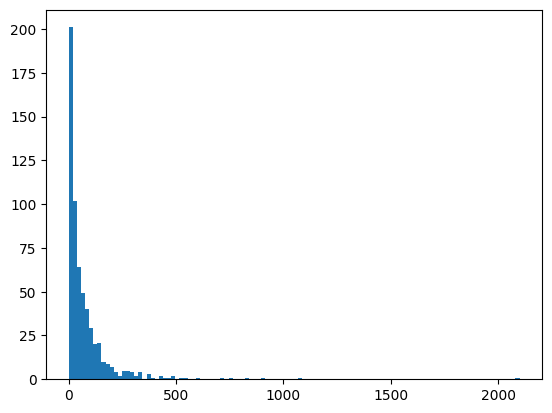

In [8]:
plt.hist(df_clean['T90'], bins='fd')

Text(0, 0.5, 'PC2')

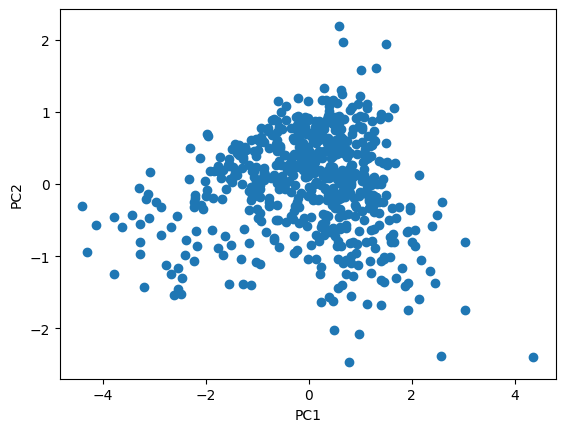

In [21]:
X = df_clean[['T90', 'fluence']].to_numpy()
X = np.log10(X)  # log-transform to reduce skew

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")

###  1 method: KMeans

Text(0, 0.5, 'PC2')

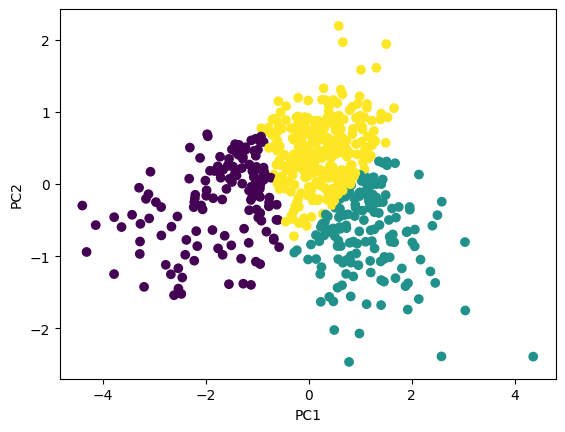

In [20]:
kmeans = KMeans(n_clusters=3, n_init='auto')
labels_km = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km)
plt.xlabel("PC1")
plt.ylabel("PC2")

### 2 method: MeanShift

Text(0, 0.5, 'PC2')

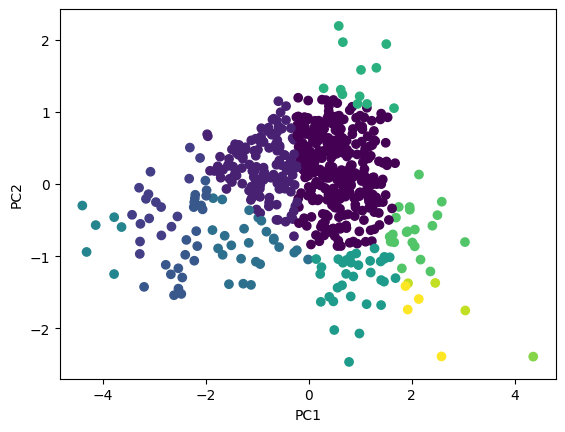

In [24]:
ms = MeanShift(bandwidth=0.6, bin_seeding=True)
labels_ms = ms.fit_predict(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_ms)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [23]:
len(np.unique(labels_ms))

12